# results: Fairness and bias in LMs over time with 6-8B models

In [1]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr, pearsonr, linregress

In [2]:
# paths
OUT_DIR = "results_fairness_over_time_6to8b"
SUMMARY_CSV = os.path.join(OUT_DIR, "summary_all_models.csv")
GROUPS_CSV  = os.path.join(OUT_DIR, "groups_all_models.csv")

df_sum = pd.read_csv(SUMMARY_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)
df_groups = pd.read_csv(GROUPS_CSV).sort_values(["year", "model_id", "group"]).reset_index(drop=True)

df_sum.head(), df_groups.head()

(   year                           model_id  batch_size  max_len  \
 0  2021                EleutherAI/gpt-j-6b           4      128   
 1  2022  EleutherAI/pythia-6.9b-deduped-v0           4      128   
 2  2022          EleutherAI/pythia-6.9b-v0           4      128   
 3  2022               bigscience/bloom-7b1           4      128   
 4  2022                  facebook/opt-6.7b           4      128   
 
    trust_remote_code  base_rate_cal  threshold_t  test_acc  test_pos_rate  \
 0              False          0.115     0.633410     0.815          0.110   
 1              False          0.115     0.543309     0.803          0.112   
 2              False          0.115     0.432063     0.798          0.101   
 3              False          0.115     0.689306     0.792          0.131   
 4              False          0.115     0.531433     0.790          0.113   
 
    test_fpr  ...  pos_rate_var  fpr_minmax_abs  fpr_minmax_rel   fpr_var  \
 0  0.098976  ...      0.004338        0.20

In [3]:
FAIR_ABS = "avg_minmax_abs"
FAIR_REL = "avg_minmax_rel"
FAIR_VAR = "avg_var"

In [4]:
# recompute fairness from group file
def summarize_across_groups(values, eps=1e-12):
    vals = np.array([v for v in values if not np.isnan(v)], dtype=float)
    if len(vals) == 0:
        return {"minmax_abs": np.nan, "minmax_rel": np.nan, "var": np.nan}
    mm = float(vals.max() - vals.min())
    rel = float(mm / (vals.mean() + eps))
    var = float(vals.var())
    return {"minmax_abs": mm, "minmax_rel": rel, "var": var}

def fairness_from_groups(df_g_one_model):
    out = {}
    for metric in ["acc", "pos_rate", "fpr", "fnr"]:
        vals = df_g_one_model[metric].astype(float).to_numpy()
        s = summarize_across_groups(vals)
        out[f"{metric}_minmax_abs_recalc"] = s["minmax_abs"]
        out[f"{metric}_minmax_rel_recalc"] = s["minmax_rel"]
        out[f"{metric}_var_recalc"] = s["var"]
    out["avg_minmax_abs_recalc"] = float(np.nanmean([
        out["acc_minmax_abs_recalc"], out["pos_rate_minmax_abs_recalc"],
        out["fpr_minmax_abs_recalc"], out["fnr_minmax_abs_recalc"]
    ]))
    out["avg_minmax_rel_recalc"] = float(np.nanmean([
        out["acc_minmax_rel_recalc"], out["pos_rate_minmax_rel_recalc"],
        out["fpr_minmax_rel_recalc"], out["fnr_minmax_rel_recalc"]
    ]))
    out["avg_var_recalc"] = float(np.nanmean([
        out["acc_var_recalc"], out["pos_rate_var_recalc"],
        out["fpr_var_recalc"], out["fnr_var_recalc"]
    ]))
    return out

# merge recalc metrics into df_sum
recalc_rows = []
for (year, model_id), df_gm in df_groups.groupby(["year", "model_id"]):
    row = {"year": int(year), "model_id": str(model_id)}
    row.update(fairness_from_groups(df_gm))
    recalc_rows.append(row)

df_recalc = pd.DataFrame(recalc_rows)
df = df_sum.merge(df_recalc, on=["year", "model_id"], how="left").sort_values(["year", "model_id"]).reset_index(drop=True)

BAD_MODEL_ID = "stabilityai/stablelm-base-alpha-7b-v2" # model that needs to be excluded because it labels everything as non-toxic

df = df[df["model_id"] != BAD_MODEL_ID].copy().reset_index(drop=True)
df_groups = df_groups[df_groups["model_id"] != BAD_MODEL_ID].copy().reset_index(drop=True)

df.head()

,year,model_id,batch_size,max_len,trust_remote_code,base_rate_cal,threshold_t,test_acc,test_pos_rate,test_fpr,...,pos_rate_var_recalc,fpr_minmax_abs_recalc,fpr_minmax_rel_recalc,fpr_var_recalc,fnr_minmax_abs_recalc,fnr_minmax_rel_recalc,fnr_var_recalc,avg_minmax_abs_recalc,avg_minmax_rel_recalc,avg_var_recalc
0,2021,EleutherAI/gpt-j-6b,4,128,False,0.115,0.633410,0.815,0.110,0.098976,...,0.004338,0.204861,1.276758,0.003627,0.357143,0.421305,0.015984,0.280332,0.903674,0.009505
1,2022,EleutherAI/pythia-6.9b-deduped-v0,4,128,False,0.115,0.543309,0.803,0.112,0.106940,...,0.001674,0.177778,1.241844,0.003577,0.333333,0.376233,0.009475,0.247650,0.799942,0.006975
2,2022,EleutherAI/pythia-6.9b-v0,4,128,False,0.115,0.432063,0.798,0.101,0.103527,...,0.001192,0.194737,1.307541,0.003841,0.235294,0.263602,0.004531,0.222528,0.735409,0.005837
3,2022,bigscience/bloom-7b1,4,128,False,0.115,0.689306,0.792,0.131,0.124005,...,0.000586,0.154971,1.016714,0.002109,0.214286,0.281859,0.006873,0.168864,0.515402,0.004168
4,2022,facebook/opt-6.7b,4,128,False,0.115,0.531433,0.790,0.113,0.114903,...,0.000769,0.147368,1.307503,0.001727,0.178571,0.209308,0.002225,0.181300,0.697224,0.004801


In [ ]:
# helper functions for plotting

def scatter_models_legend(
    df,
    xcol,
    ycol,
    title,
    xlabel,
    ylabel,
    x_is_year=False,
    add_line=True,
    line_type="year_mean",   
    corr_method="spearman",  
    show_stats=True,
    stats_loc="inside"     
):
    fig, ax = plt.subplots(figsize=(15, 6))

    # scatter points, one color per model
    for model_id, sub in df.groupby("model_id", sort=False):
        x = sub[xcol].astype(int) if x_is_year else sub[xcol].astype(float)
        y = sub[ycol].astype(float)
        ax.scatter(x, y, label=model_id)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if x_is_year:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        years = sorted(df[xcol].dropna().astype(int).unique())
        ax.set_xticks(years)

    ax.grid(True, linewidth=0.5, alpha=0.5)

    # numeric data for line / correlation
    sub_num = df[[xcol, ycol]].dropna().copy()
    x_all = sub_num[xcol].astype(int).to_numpy() if x_is_year else sub_num[xcol].astype(float).to_numpy()
    y_all = sub_num[ycol].astype(float).to_numpy()

    # add line
    if add_line and len(sub_num) >= 2:
        if line_type == "year_mean" and x_is_year:
            mean_line = (
                sub_num.groupby(xcol, as_index=False)[ycol]
                .mean()
                .sort_values(xcol)
            )
            ax.plot(
                mean_line[xcol].astype(int),
                mean_line[ycol].astype(float),
                marker="o",
                linewidth=2,
                label="Year mean"
            )

        elif line_type == "fit":
            slope, intercept, _, _, _ = linregress(x_all, y_all)
            xs = np.linspace(x_all.min(), x_all.max(), 200)
            ys = intercept + slope * xs
            ax.plot(xs, ys, linestyle="--", linewidth=2, label="Linear fit")

    # correlation
    stats_text = None
    if show_stats and len(sub_num) >= 2:
        if corr_method == "spearman":
            rho, pval = spearmanr(x_all, y_all)
            stats_text = f"Spearman's $\\rho$ = {rho:.3f}\np = {pval:.4g}"
        elif corr_method == "pearson":
            rho, pval = pearsonr(x_all, y_all)
            stats_text = f"Pearson's $r$ = {rho:.3f}\np = {pval:.4g}"

    if stats_text is not None:
        if stats_loc == "inside":
            ax.text(
                0.02, 0.98,
                stats_text,
                transform=ax.transAxes,
                va="top",
                ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
            )
        elif stats_loc == "below":
            fig.text(0.12, 0.02, stats_text, ha="left", va="bottom", fontsize=10)

    n_models = df["model_id"].nunique()
    fontsize = 8 if n_models <= 20 else 6

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        fontsize=fontsize
    )

    if stats_loc == "below":
        fig.tight_layout(rect=[0, 0.08, 0.75, 1])
    else:
        fig.tight_layout(rect=[0, 0, 0.75, 1])

    plt.show()


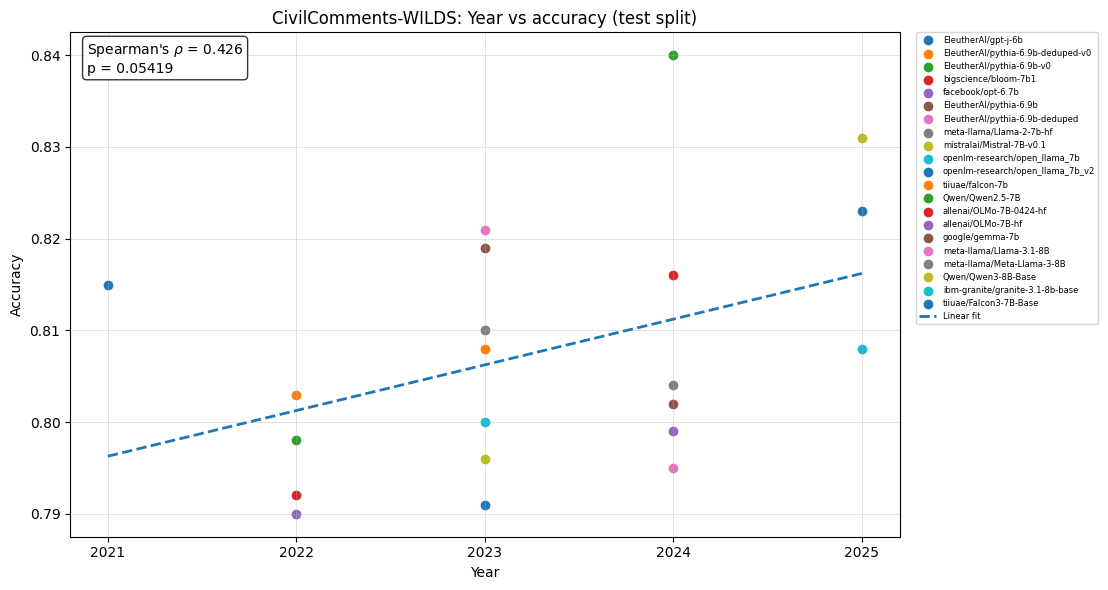

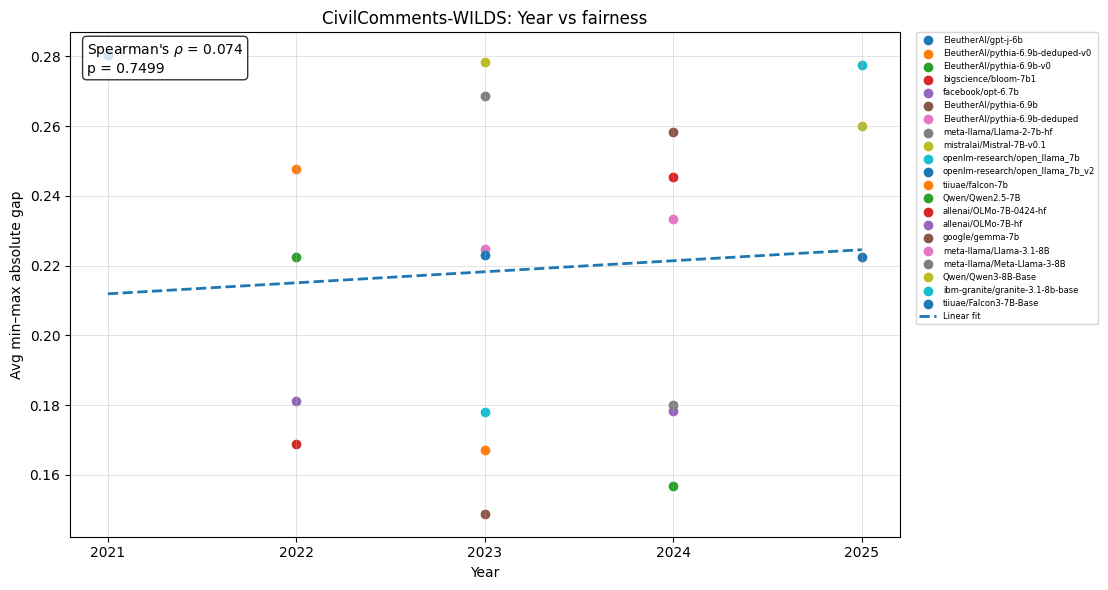

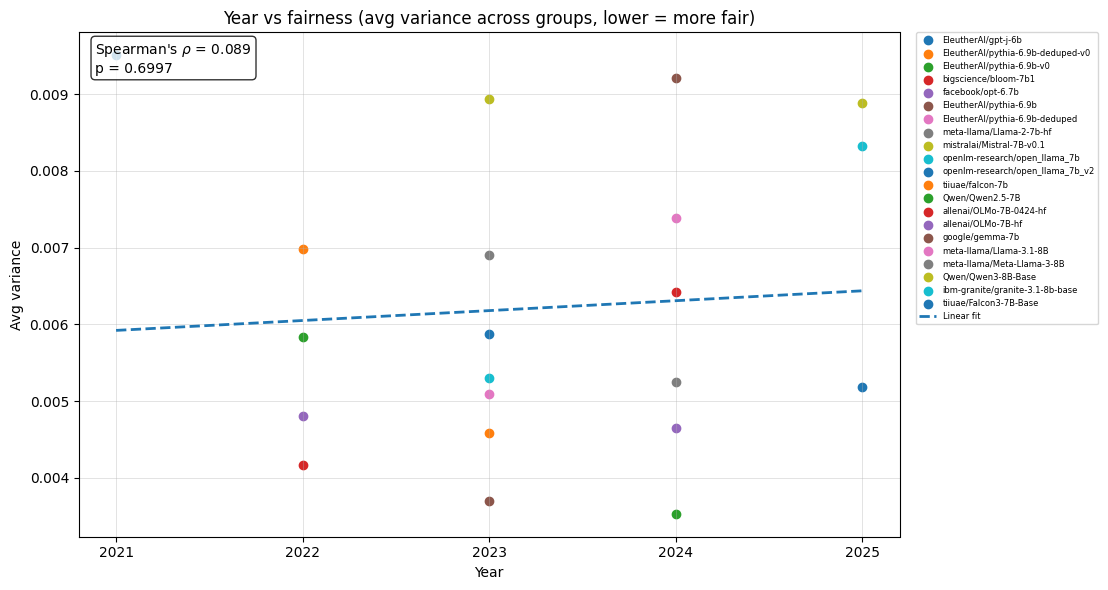

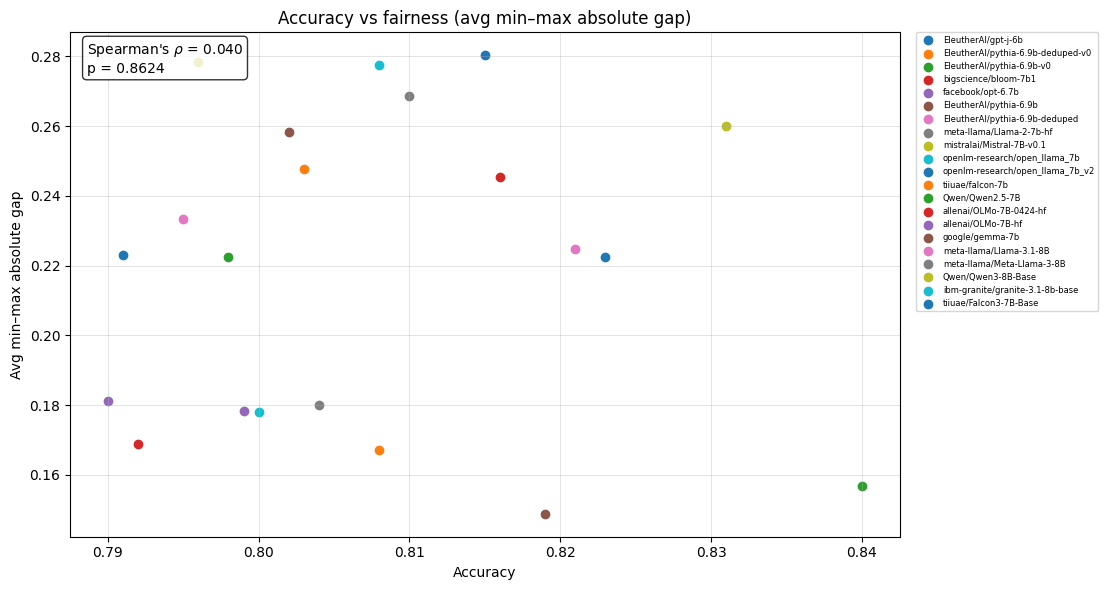

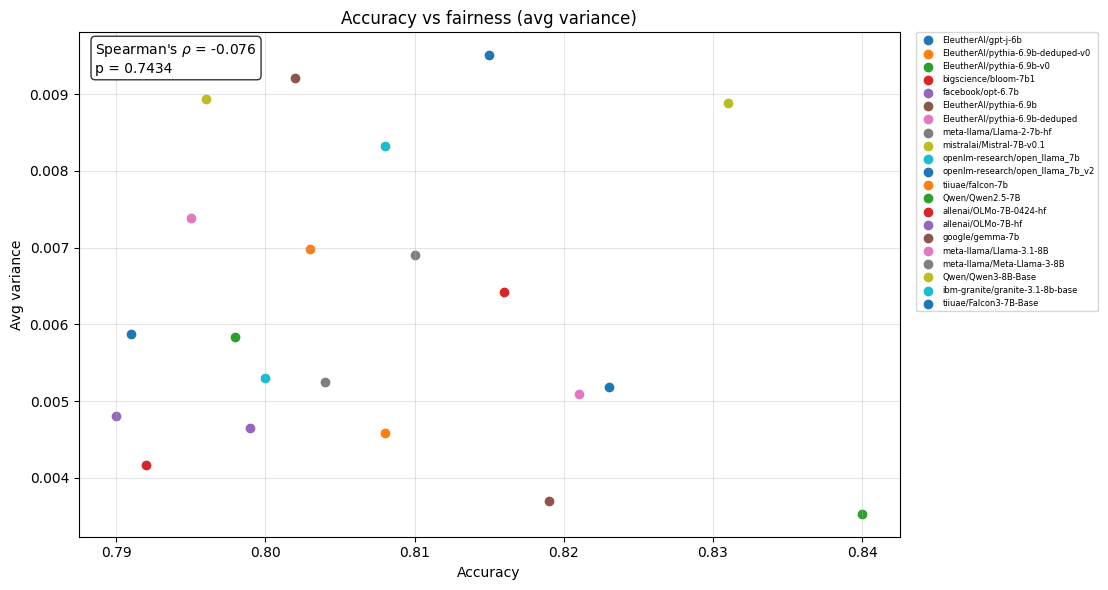

In [6]:
scatter_models_legend(df, "year", "test_acc",
                      "CivilComments-WILDS: Year vs accuracy (test split)",
                      "Year", "Accuracy",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

scatter_models_legend(df, "year", FAIR_ABS,
                      "CivilComments-WILDS: Year vs fairness", # (avg min–max absolute gap)
                      "Year", "Avg min–max absolute gap",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

scatter_models_legend(df, "year", FAIR_VAR,
                      "Year vs fairness (avg variance across groups, lower = more fair)",
                      "Year", "Avg variance",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

scatter_models_legend(df, "test_acc", FAIR_ABS,
                      "Accuracy vs fairness (avg min–max absolute gap)",
                      "Accuracy", "Avg min–max absolute gap",
                      x_is_year=False)

scatter_models_legend(df, "test_acc", FAIR_VAR,
                      "Accuracy vs fairness (avg variance)",
                      "Accuracy", "Avg variance",
                      x_is_year=False)

In [7]:
# detecting the outlier in year vs accuracy, just to make sure that everything looks ok
df.sort_values("test_acc", ascending=False)[
    ["year", "model_id", "test_acc", "test_pos_rate", "test_fpr", "test_fnr", "threshold_t"]
].head(10)

,year,model_id,test_acc,test_pos_rate,test_fpr,test_fnr,threshold_t
12,2024,Qwen/Qwen2.5-7B,0.840,0.113,0.086462,0.694215,0.585319
18,2025,Qwen/Qwen3-8B-Base,0.831,0.122,0.096701,0.694215,0.453262
20,2025,tiiuae/Falcon3-7B-Base,0.823,0.114,0.096701,0.760331,0.651559
6,2023,EleutherAI/pythia-6.9b-deduped,0.821,0.098,0.088737,0.834711,0.503906
5,2023,EleutherAI/pythia-6.9b,0.819,0.092,0.086462,0.867769,0.721743
13,2024,allenai/OLMo-7B-0424-hf,0.816,0.111,0.098976,0.801653,0.345105
0,2021,EleutherAI/gpt-j-6b,0.815,0.110,0.098976,0.809917,0.633410
7,2023,meta-llama/Llama-2-7b-hf,0.810,0.113,0.103527,0.818182,0.778727
11,2023,tiiuae/falcon-7b,0.808,0.085,0.088737,0.942149,0.539011
19,2025,ibm-granite/granite-3.1-8b-base,0.808,0.127,0.112628,0.768595,0.985509


so, stabilityai/stablelm-base-alpha-7b-v2 will be excluded due to numerical issues

In [8]:
# compact tables
perf_cols = ["year","model_id","threshold_t","test_acc","test_pos_rate","test_fpr","test_fnr"]
fair_cols = ["year","model_id",
             "acc_minmax_abs","acc_minmax_rel","acc_var",
             "pos_rate_minmax_abs","pos_rate_minmax_rel","pos_rate_var",
             "fpr_minmax_abs","fpr_minmax_rel","fpr_var",
             "fnr_minmax_abs","fnr_minmax_rel","fnr_var",
             "avg_minmax_abs","avg_minmax_rel","avg_var"]

perf_tbl = df[perf_cols].copy().sort_values(["year","model_id"])
fair_tbl = df[fair_cols].copy().sort_values(["year","model_id"])

perf_tbl, fair_tbl

(    year                           model_id  threshold_t  test_acc  \
 0   2021                EleutherAI/gpt-j-6b     0.633410     0.815   
 1   2022  EleutherAI/pythia-6.9b-deduped-v0     0.543309     0.803   
 2   2022          EleutherAI/pythia-6.9b-v0     0.432063     0.798   
 3   2022               bigscience/bloom-7b1     0.689306     0.792   
 4   2022                  facebook/opt-6.7b     0.531433     0.790   
 5   2023             EleutherAI/pythia-6.9b     0.721743     0.819   
 6   2023     EleutherAI/pythia-6.9b-deduped     0.503906     0.821   
 7   2023           meta-llama/Llama-2-7b-hf     0.778727     0.810   
 8   2023          mistralai/Mistral-7B-v0.1     0.513668     0.796   
 9   2023      openlm-research/open_llama_7b     0.378843     0.800   
 10  2023   openlm-research/open_llama_7b_v2     0.637031     0.791   
 11  2023                   tiiuae/falcon-7b     0.539011     0.808   
 12  2024                    Qwen/Qwen2.5-7B     0.585319     0.840   
 13  2

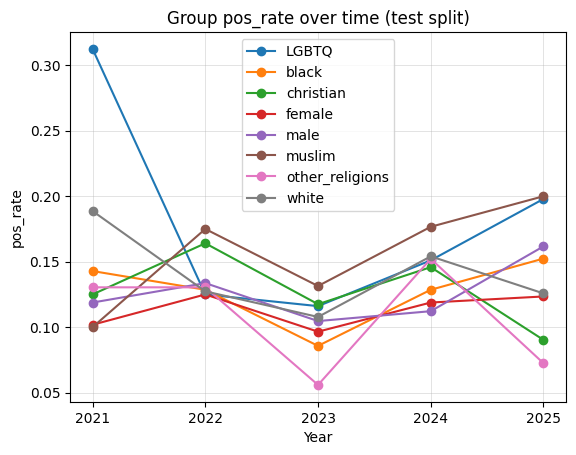

In [9]:
# group level trens for one metric
def plot_group_metric_over_time(df_groups, metric="acc"):
    wide = df_groups.pivot_table(index="year", columns="group", values=metric, aggfunc="mean").sort_index()
    plt.figure()
    for g in wide.columns:
        plt.plot(wide.index, wide[g], marker="o", label=g)
    plt.xticks(wide.index)
    plt.title(f"Group {metric} over time (test split)")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linewidth=0.5, alpha=0.5)
    plt.legend()
    plt.show()

plot_group_metric_over_time(df_groups, metric="pos_rate")

# bias

In [ ]:
# adding crowS to df
BIAS_CSV = os.path.join(OUT_DIR, "bias_crows_pairs.csv")

df_bias = pd.read_csv(BIAS_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)

# make sure types match 
df["year"] = df["year"].astype(int)
df["model_id"] = df["model_id"].astype(str)
df_bias["year"] = df_bias["year"].astype(int)
df_bias["model_id"] = df_bias["model_id"].astype(str)

# merge in bias
df = df.merge(df_bias[["year", "model_id", "crows_bias"]], on=["year", "model_id"], how="left")

# sanity check
print("Missing bias rows:", df["crows_bias"].isna().sum(), "/", len(df))
df[["year", "model_id", "test_acc", "crows_bias"]].head()


Missing bias rows: 1 / 21


,year,model_id,test_acc,crows_bias
0,2021,EleutherAI/gpt-j-6b,0.815,55.702918
1,2022,EleutherAI/pythia-6.9b-deduped-v0,0.803,55.106101
2,2022,EleutherAI/pythia-6.9b-v0,0.798,55.503979
3,2022,bigscience/bloom-7b1,0.792,58.687003
4,2022,facebook/opt-6.7b,0.790,55.702918


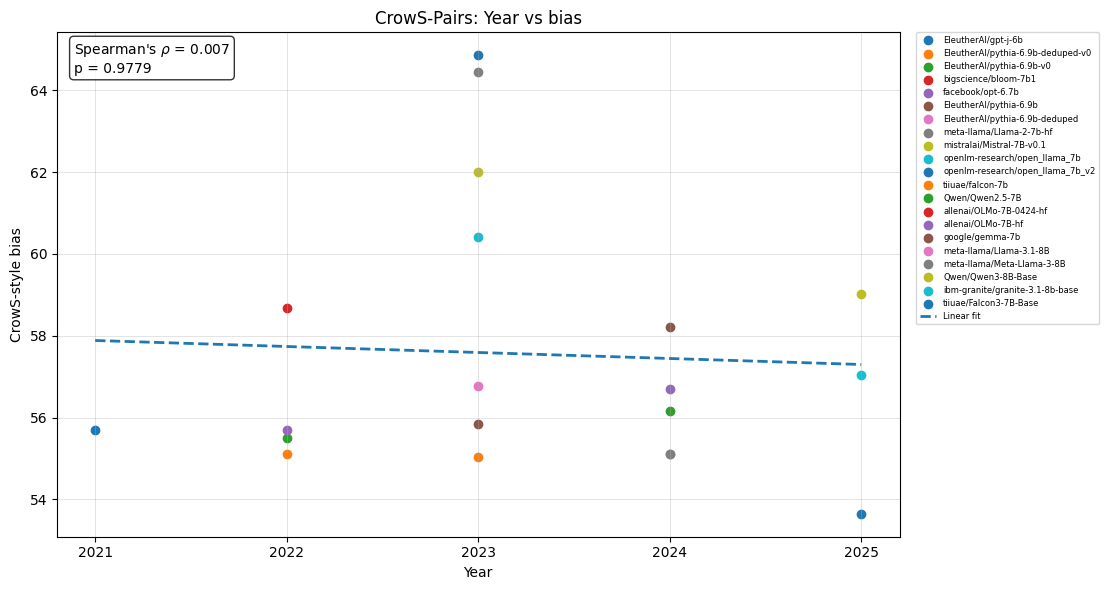

In [ ]:
# year vs bias
scatter_models_legend(df, "year", "crows_bias",
                      "CrowS-Pairs: Year vs bias", # higher = more stereotypical preference
                      "Year", "CrowS-style bias",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")


avg for each year

In [ ]:
# helper functions
def bootstrap_mean_ci(x, n_boot=5000, ci=95, seed=42):
    """
    Bootstrap CI for the mean of a 1D array.
    Returns mean, ci_low, ci_high, n, std.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)

    if n == 0:
        return pd.Series({
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan
        })

    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if n > 1 else 0.0

    # if only one model in a year, CI is just the point itself
    if n == 1:
        ci_low = mean
        ci_high = mean
    else:
        rng = np.random.default_rng(seed)
        boot_means = np.empty(n_boot, dtype=float)

        for b in range(n_boot):
            sample = rng.choice(x, size=n, replace=True)
            boot_means[b] = sample.mean()

        alpha = (100 - ci) / 2
        ci_low, ci_high = np.percentile(boot_means, [alpha, 100 - alpha])

    return pd.Series({
        "n": n,
        "mean": mean,
        "std": std,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high)
    })


def summarize_by_year(df, value_col, n_boot=5000, ci=95, seed=42):
    rows = []

    for year, sub in df.groupby("year"):
        stats = bootstrap_mean_ci(sub[value_col].to_numpy(), n_boot=n_boot, ci=ci, seed=seed)
        rows.append({
            "year": int(year),
            "n": stats["n"],
            "mean": stats["mean"],
            "std": stats["std"],
            "ci_low": stats["ci_low"],
            "ci_high": stats["ci_high"],
        })

    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def plot_year_mean_ci(summary_df, title, ylabel):
    """
    Plot yearly mean with CI error bars.
    """
    x = summary_df["year"].astype(int).to_numpy()
    y = summary_df["mean"].astype(float).to_numpy()
    low = summary_df["ci_low"].astype(float).to_numpy()
    high = summary_df["ci_high"].astype(float).to_numpy()

    yerr = np.vstack([y - low, high - y])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=4, color="deeppink", ecolor="deepskyblue")

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(summary_df["year"].unique()))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.show()

In [13]:
# build year-level summaries
year_acc = summarize_by_year(df, "test_acc", n_boot=5000, ci=95, seed=42)
year_fair = summarize_by_year(df, FAIR_ABS, n_boot=5000, ci=95, seed=42)
year_bias = summarize_by_year(df, "crows_bias", n_boot=5000, ci=95, seed=42)

print("Year-level mean accuracy")
display(year_acc.round(4))

print("Year-level mean fairness")
display(year_fair.round(4))

print("Year-level mean bias")
display(year_bias.round(4))

Year-level mean accuracy


,year,n,mean,std,ci_low,ci_high
0,2021,1.0,0.8150,0.0000,0.8150,0.8150
1,2022,4.0,0.7958,0.0059,0.7910,0.8005
2,2023,7.0,0.8064,0.0114,0.7986,0.8140
3,2024,6.0,0.8093,0.0166,0.7992,0.8225
4,2025,3.0,0.8207,0.0117,0.8080,0.8310


Year-level mean fairness


,year,n,mean,std,ci_low,ci_high
0,2021,1.0,0.2803,0.0000,0.2803,0.2803
1,2022,4.0,0.2051,0.0365,0.1751,0.2351
2,2023,7.0,0.2127,0.0500,0.1786,0.2469
3,2024,6.0,0.2087,0.0421,0.1789,0.2389
4,2025,3.0,0.2534,0.0281,0.2226,0.2775


Year-level mean bias


,year,n,mean,std,ci_low,ci_high
0,2021,1.0,55.7029,0.0000,55.7029,55.7029
1,2022,4.0,56.2500,1.6435,55.2553,57.8912
2,2023,7.0,59.9091,4.0817,57.1803,62.7804
3,2024,5.0,56.2599,1.2957,55.3183,57.2944
4,2025,3.0,56.5650,2.7156,53.6472,59.0186
